# Лабораторна робота №1. Підготовка статистичних даних: читання, описова статистика, очистка
# Варіант 001 — Освіта
# Каламаж Володимир Група: АтаВДвR-11
# Підготовка статистичних даних та очистка
## Мета

1. Навчитися **генерувати синтетичні дані** із контрольованими проблемами якості.
2. Провести **описову статистику** до та після очистки.
3. Розробити й реалізувати **план очистки даних** (пропуски, дублі, типи, аномалії).
4. Порівняти показники «до/після» і зробити **висновки про вплив очистки**.
5. Отримати з очищених даних **10 узгоджених показників (KPI)**.

In [ ]:

# Фіксуємо random seed для відтворюваності
random_seed <- 12345
set.seed(random_seed)

# Створюємо структуру папок
dir.create("data", showWarnings = FALSE)
dir.create("data/raw", showWarnings = FALSE)
dir.create("data/clean", showWarnings = FALSE)

# Підключаємо бібліотеки
library(dplyr)
library(tidyr)
library(stringr)
library(lubridate)
library(ggplot2)
library(readr)
library(purrr)

cat("Random seed:", random_seed, "\n")
cat("R version:", R.version.string, "\n")


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching package: ‘lubridate’

The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union

Random seed: 12345 
R version: R version 4.6.1 (2026-06-24 ucrt) 


# БЛОК 1. Генерація даних

In [ ]:

set.seed(random_seed)

# Кількість основних записів
n <- 1800

# -----------------------------
# Студенти
# -----------------------------

n_students <- 350

student_ids <- sprintf("ST%03d", 1:n_students)

student_surnames <- c(
  "Шевченко", "Коваленко", "Бондаренко", "Ткаченко",
  "Мельник", "Кравченко", "Олійник", "Гнатюк",
  "Петренко", "Іваненко", "Сидоренко", "Мороз",
  "Лисенко", "Романенко", "Савченко", "Поліщук",
  "Білик", "Данилюк", "Марченко", "Клименко"
)

student_names_first <- c(
  "Олександр", "Андрій", "Максим", "Дмитро",
  "Владислав", "Богдан", "Іван", "Микола",
  "Анастасія", "Марія", "Софія", "Анна",
  "Катерина", "Олена", "Вікторія", "Дарина"
)

student_patronymics <- c(
  "Олександрович", "Андрійович", "Максимович",
  "Дмитрович", "Владиславович", "Богданович",
  "Іванович", "Миколайович", "Олександрівна",
  "Андріївна", "Максимівна", "Дмитрівна",
  "Іванівна", "Миколаївна"
)

students <- tibble(
  student_id = student_ids,
  student_name = paste(
    sample(student_surnames, n_students, replace = TRUE),
    sample(student_names_first, n_students, replace = TRUE),
    sample(student_patronymics, n_students, replace = TRUE)
  ),
  group = sample(
    c("K-21", "K-22", "K-23", "K-24"),
    n_students,
    replace = TRUE
  )
)

# -----------------------------
# Основний журнал
# -----------------------------

dirty_data <- tibble(
  record_id = sprintf("REC%04d", 1:n),
  
  date = sample(
    seq(
      as.Date("2024-02-05"),
      as.Date("2024-06-30"),
      by = "day"
    ),
    n,
    replace = TRUE
  ),
  
  student_id = sample(
    student_ids,
    n,
    replace = TRUE
  ),
  
  subject = sample(
    c("DA-101", "DA-102"),
    n,
    replace = TRUE
  ),
  
  attempt = sample(
    c(1, 2),
    n,
    replace = TRUE,
    prob = c(0.85, 0.15)
  ),
  
  attendance = sample(
    c("Present", "Absent", "Late"),
    n,
    replace = TRUE,
    prob = c(0.75, 0.15, 0.10)
  ),
  
  score = round(
    pmin(
      pmax(
        rnorm(n, mean = 75, sd = 15),
        0
      ),
      100
    ),
    1
  ),
  
  teacher = sample(
    c("Ivanenko", "Petrenko"),
    n,
    replace = TRUE
  ),
  
  comment = sample(
    c(
      "Good work",
      "Needs improvement",
      "Excellent",
      "Was late",
      "Missed class",
      "Good progress",
      "Additional task"
    ),
    n,
    replace = TRUE
  )
)

# Додаємо ім'я та групу студента
dirty_data <- dirty_data %>%
  left_join(students, by = "student_id") %>%
  select(
    record_id,
    date,
    student_id,
    student_name,
    group,
    subject,
    attempt,
    attendance,
    score,
    teacher,
    comment
  )

# Перемішуємо рядки
dirty_data <- dirty_data %>%
  slice_sample(prop = 1) %>%
  mutate(record_id = sprintf("REC%04d", row_number()))

cat("Кількість рядків:", nrow(dirty_data), "\n")
cat("Кількість стовпців:", ncol(dirty_data), "\n")

head(dirty_data)

Кількість рядків: 1800 
Кількість стовпців: 11 


# A tibble: 6 × 11
  record_id date       student_id student_name  group subject attempt attendance
  <chr>     <date>     <chr>      <chr>         <chr> <chr>     <dbl> <chr>     
1 REC0001   2024-06-16 ST128      Шевченко Дар… K-21  DA-102        1 Present   
2 REC0002   2024-03-08 ST150      Білик Микола… K-23  DA-101        1 Absent    
3 REC0003   2024-03-17 ST320      Бондаренко К… K-23  DA-102        1 Late      
4 REC0004   2024-04-30 ST044      Лисенко Марі… K-23  DA-102        1 Present   
5 REC0005   2024-06-24 ST035      Мельник Кате… K-23  DA-101        1 Present   
6 REC0006   2024-05-27 ST088      Клименко Оле… K-22  DA-102        1 Absent    
# ℹ 3 more variables: score <dbl>, teacher <chr>, comment <chr>

In [3]:
# -----------------------------
# Пропуски
# -----------------------------

set.seed(random_seed + 1)

# SCORE — приблизно 15%
# Частіше пропуски для K-24 та Absent

score_probability <- case_when(
  dirty_data$group == "K-24" ~ 0.25,
  dirty_data$attendance == "Absent" ~ 0.25,
  TRUE ~ 0.12
)

score_missing <- runif(nrow(dirty_data)) < score_probability

# Коригуємо до приблизно 15% загальних пропусків
target_score_missing <- round(0.15 * nrow(dirty_data))

if (sum(score_missing) < target_score_missing) {
  candidates <- which(!score_missing)
  additional <- sample(
    candidates,
    target_score_missing - sum(score_missing)
  )
  score_missing[additional] <- TRUE
}

dirty_data$score[score_missing] <- NA

# ATTENDANCE — приблизно 7%
attendance_missing <- sample(
  seq_len(nrow(dirty_data)),
  round(0.07 * nrow(dirty_data))
)

dirty_data$attendance[attendance_missing] <- NA

# DATE — приблизно 4%
date_missing <- sample(
  seq_len(nrow(dirty_data)),
  round(0.04 * nrow(dirty_data))
)

dirty_data$date[date_missing] <- NA

# COMMENT — приблизно 6%
comment_missing <- sample(
  seq_len(nrow(dirty_data)),
  round(0.06 * nrow(dirty_data))
)

dirty_data$comment[comment_missing] <- NA

# Перевірка
missing_summary <- dirty_data %>%
  summarise(
    across(
      everything(),
      ~ round(mean(is.na(.)) * 100, 2)
    )
  )

missing_summary

# A tibble: 1 × 11
  record_id  date student_id student_name group subject attempt attendance score
      <dbl> <dbl>      <dbl>        <dbl> <dbl>   <dbl>   <dbl>      <dbl> <dbl>
1         0     4          0            0     0       0       0          7  15.5
# ℹ 2 more variables: teacher <dbl>, comment <dbl>

In [4]:
# -----------------------------
# Формати дат
# -----------------------------

set.seed(random_seed + 2)

# 10% непорожніх дат переводимо у формат DD.MM.YYYY
valid_dates <- which(!is.na(dirty_data$date))

date_text <- as.character(dirty_data$date)

n_date_text <- round(0.10 * length(valid_dates))

date_text_rows <- sample(
  valid_dates,
  n_date_text
)

date_text[date_text_rows] <- format(
  dirty_data$date[date_text_rows],
  "%d.%m.%Y"
)

dirty_data$date <- date_text

# Перевіряємо приклади
head(
  dirty_data %>%
    select(record_id, date),
  20
)

# A tibble: 20 × 2
   record_id date      
   <chr>     <chr>     
 1 REC0001   2024-06-16
 2 REC0002   2024-03-08
 3 REC0003   2024-03-17
 4 REC0004   2024-04-30
 5 REC0005   2024-06-24
 6 REC0006   2024-05-27
 7 REC0007   2024-05-01
 8 REC0008   2024-04-26
 9 REC0009   2024-06-13
10 REC0010   2024-03-11
11 REC0011   2024-03-25
12 REC0012   2024-05-17
13 REC0013   2024-06-26
14 REC0014   2024-03-11
15 REC0015   11.06.2024
16 REC0016   2024-02-26
17 REC0017   2024-03-20
18 REC0018   2024-04-12
19 REC0019   2024-02-09
20 REC0020   2024-02-25

In [5]:
# -----------------------------
# Змішані типи score
# -----------------------------

set.seed(random_seed + 3)

# Щоб мати можливість зберігати і числа, і текст,
# переводимо score у character
dirty_data$score <- as.character(dirty_data$score)

valid_scores <- which(!is.na(dirty_data$score))

n_text_scores <- round(0.08 * length(valid_scores))

score_text_rows <- sample(
  valid_scores,
  n_text_scores
)

# Формат: " 95,0"
dirty_data$score[score_text_rows] <- paste0(
  " ",
  str_replace(
    dirty_data$score[score_text_rows],
    "\\.",
    ","
  )
)

# Кілька прикладів
dirty_data %>%
  select(record_id, score) %>%
  slice_sample(n = 20)

# A tibble: 20 × 2
   record_id score  
   <chr>     <chr>  
 1 REC0010   "57.2" 
 2 REC1750   "52"   
 3 REC1763   "81.9" 
 4 REC1125   "88.2" 
 5 REC0548   "65.5" 
 6 REC1593   " 71,2"
 7 REC1309   "58.9" 
 8 REC1799    NA    
 9 REC1762    NA    
10 REC0783   "82.9" 
11 REC0403   "60.6" 
12 REC1798   "63.5" 
13 REC0590    NA    
14 REC1404    NA    
15 REC0923   "84.2" 
16 REC0667   "90.2" 
17 REC1710   "87.7" 
18 REC1068    NA    
19 REC0765   "80.9" 
20 REC1729   "90.9" 

In [6]:
# -----------------------------
# Нестабільні категорії
# -----------------------------

set.seed(random_seed + 4)

# Attendance
attendance_rows <- sample(
  which(!is.na(dirty_data$attendance)),
  round(0.20 * sum(!is.na(dirty_data$attendance)))
)

dirty_data$attendance[attendance_rows] <- sample(
  c("PRESENT ", "present", "abs", "Late "),
  length(attendance_rows),
  replace = TRUE
)

# Subject
subject_rows <- sample(
  seq_len(nrow(dirty_data)),
  round(0.20 * nrow(dirty_data))
)

dirty_data$subject[subject_rows] <- ifelse(
  dirty_data$subject[subject_rows] == "DA-101",
  sample(c("DA 101", "da-101", "DA-101"),
         length(subject_rows), replace = TRUE),
  sample(c("DA 102", "da-102", "DA-102"),
         length(subject_rows), replace = TRUE)
)

# Teacher
teacher_rows <- sample(
  seq_len(nrow(dirty_data)),
  round(0.15 * nrow(dirty_data))
)

dirty_data$teacher[teacher_rows] <- sample(
  c("ivanenko", "IVANENKO ", "petrenko", "PETRENKO "),
  length(teacher_rows),
  replace = TRUE
)

# Перевіряємо категорії
unique(dirty_data$attendance)
unique(dirty_data$subject)
unique(dirty_data$teacher)

[1] "petrenko"  "Ivanenko"  "ivanenko"  "Petrenko"  "IVANENKO " "PETRENKO "

In [7]:
# -----------------------------
# Помилки в іменах студентів
# -----------------------------

set.seed(random_seed + 5)

# Частину імен переводимо у різний регістр
name_rows <- sample(
  seq_len(nrow(dirty_data)),
  round(0.10 * nrow(dirty_data))
)

dirty_data$student_name[name_rows] <- sample(
  c(
    str_to_upper(dirty_data$student_name[name_rows]),
    str_to_lower(dirty_data$student_name[name_rows]),
    str_to_title(dirty_data$student_name[name_rows])
  ),
  length(name_rows),
  replace = TRUE
)

# 12 навмисних опечаток
typo_rows <- sample(
  which(!is.na(dirty_data$student_name)),
  12
)

for (i in typo_rows) {
  old_name <- dirty_data$student_name[i]
  
  # Заміна "юк" на "иук" як приклад опечатки
  dirty_data$student_name[i] <- str_replace(
    old_name,
    "юк",
    "иук"
  )
}

# Декілька зайвих пробілів
space_rows <- sample(
  which(!is.na(dirty_data$student_name)),
  20
)

dirty_data$student_name[space_rows] <- paste0(
  "  ",
  dirty_data$student_name[space_rows],
  " "
)

# Перевірка
dirty_data %>%
  select(student_id, student_name) %>%
  slice_sample(n = 15)

# A tibble: 15 × 2
   student_id student_name                   
   <chr>      <chr>                          
 1 ST128      Шевченко Дарина Максимівна     
 2 ST014      Шевченко Катерина Максимович   
 3 ST315      Білик Анастасія Іванович       
 4 ST314      ІВАНЕНКО СОФІЯ ІВАНОВИЧ        
 5 ST093      Кравченко Софія Богданович     
 6 ST095      ГНАТЮК ДМИТРО ДМИТРОВИЧ        
 7 ST209      олійник анна олександрівна     
 8 ST291      Іваненко Анна Максимівна       
 9 ST319      Петренко Микола Олександрівна  
10 ST310      Петренко Олександр Максимівна  
11 ST283      Данилюк Анастасія Олександрівна
12 ST311      Ткаченко Владислав Іванівна    
13 ST260      Білик Анастасія Миколаївна     
14 ST146      Савченко Богдан Максимович     
15 ST167      Лисенко Андрій Олександрович   

In [8]:
# -----------------------------
# Аномальні значення score
# -----------------------------

set.seed(random_seed + 6)

valid_score_rows <- which(!is.na(dirty_data$score))

n_anomalies <- round(
  0.01 * length(valid_score_rows)
)

anomaly_rows <- sample(
  valid_score_rows,
  n_anomalies
)

dirty_data$score[anomaly_rows] <- sample(
  c(
    "-15",
    "-5",
    "105",
    "110",
    "115",
    "130"
  ),
  length(anomaly_rows),
  replace = TRUE
)

# Перевірка
dirty_data %>%
  mutate(
    score_numeric_test = parse_number(
      score,
      locale = locale(decimal_mark = ",")
    )
  ) %>%
  filter(
    score_numeric_test < 0 |
    score_numeric_test > 100
  ) %>%
  select(record_id, score, score_numeric_test)

# A tibble: 1,202 × 3
   record_id score score_numeric_test
   <chr>     <chr>              <dbl>
 1 REC0001   62.1                 621
 2 REC0002   99.4                 994
 3 REC0003   68.3                 683
 4 REC0005   64.1                 641
 5 REC0006   74.5                 745
 6 REC0008   79.7                 797
 7 REC0009   44.1                 441
 8 REC0010   57.2                 572
 9 REC0011   70.8                 708
10 REC0012   62.4                 624
# ℹ 1,192 more rows
# ℹ Use `print(n = ...)` to see more rows

In [9]:
# -----------------------------
# Некоректний attempt
# -----------------------------

set.seed(random_seed + 7)

n_bad_attempt <- round(
  0.005 * nrow(dirty_data)
)

bad_attempt_rows <- sample(
  seq_len(nrow(dirty_data)),
  n_bad_attempt
)

dirty_data$attempt[bad_attempt_rows] <- 3

table(dirty_data$attempt)


   1    2    3 
1520  271    9 

In [10]:
# -----------------------------
# Логічні помилки
# -----------------------------

set.seed(random_seed + 8)

logical_error_candidates <- which(
  dirty_data$attendance == "Present" &
  dirty_data$attempt == 1
)

n_logical_errors <- round(
  0.005 * nrow(dirty_data)
)

logical_error_rows <- sample(
  logical_error_candidates,
  min(
    n_logical_errors,
    length(logical_error_candidates)
  )
)

dirty_data$score[logical_error_rows] <- NA

cat(
  "Створено логічних помилок:",
  length(logical_error_rows),
  "\n"
)

dirty_data %>%
  filter(
    attendance == "Present",
    attempt == 1,
    is.na(score)
  ) %>%
  select(
    record_id,
    student_id,
    group,
    subject,
    attempt,
    attendance,
    score
  ) %>%
  head(10)

Створено логічних помилок: 9 


# A tibble: 10 × 7
   record_id student_id group subject attempt attendance score
   <chr>     <chr>      <chr> <chr>     <dbl> <chr>      <chr>
 1 REC0004   ST044      K-23  DA-102        1 Present    NA   
 2 REC0013   ST220      K-23  DA-101        1 Present    NA   
 3 REC0026   ST183      K-21  DA-101        1 Present    NA   
 4 REC0036   ST226      K-22  DA-102        1 Present    NA   
 5 REC0056   ST124      K-22  DA-102        1 Present    NA   
 6 REC0100   ST019      K-22  DA-102        1 Present    NA   
 7 REC0124   ST143      K-21  DA-102        1 Present    NA   
 8 REC0129   ST256      K-22  da-102        1 Present    NA   
 9 REC0143   ST347      K-21  DA-101        1 Present    NA   
10 REC0144   ST284      K-21  DA-101        1 Present    NA   

In [11]:
# -----------------------------
# Повні дублікати
# -----------------------------

set.seed(random_seed + 9)

n_full_duplicates <- round(
  0.025 * nrow(dirty_data)
)

duplicate_rows <- sample(
  seq_len(nrow(dirty_data)),
  n_full_duplicates
)

full_duplicates <- dirty_data[duplicate_rows, ]

dirty_data <- bind_rows(
  dirty_data,
  full_duplicates
)

cat(
  "Додано повних дублікатів:",
  n_full_duplicates,
  "\n"
)

cat(
  "Новий розмір:",
  nrow(dirty_data),
  "\n"
)

Додано повних дублікатів: 45 
Новий розмір: 1845 


In [12]:
# -----------------------------
# Майже дублікати
# -----------------------------

set.seed(random_seed + 10)

n_near_duplicates <- round(
  0.02 * nrow(dirty_data)
)

near_rows <- sample(
  seq_len(nrow(dirty_data)),
  n_near_duplicates
)

near_duplicates <- dirty_data[near_rows, ]

# Змінюємо тільки текстові поля
near_duplicates$student_name <- paste0(
  " ",
  str_to_lower(
    near_duplicates$student_name
  ),
  " "
)

near_duplicates$subject <- str_to_lower(
  near_duplicates$subject
)

near_duplicates$attendance <- ifelse(
  is.na(near_duplicates$attendance),
  NA,
  paste0(
    " ",
    str_to_lower(
      near_duplicates$attendance
    ),
    " "
  )
)

# Нові record_id, щоб це не були повні дублікати
near_duplicates$record_id <- paste0(
  "NEAR",
  sprintf("%04d", seq_len(nrow(near_duplicates)))
)

dirty_data <- bind_rows(
  dirty_data,
  near_duplicates
)

cat(
  "Додано майже дублікатів:",
  n_near_duplicates,
  "\n"
)

cat(
  "Фінальний розмір брудного набору:",
  nrow(dirty_data),
  "\n"
)

Додано майже дублікатів: 37 
Фінальний розмір брудного набору: 1882 


In [13]:
# -----------------------------
# Бруд у текстовому полі comment
# -----------------------------

set.seed(random_seed + 11)

comment_rows <- sample(
  which(!is.na(dirty_data$comment)),
  round(0.15 * sum(!is.na(dirty_data$comment)))
)

dirty_data$comment[comment_rows] <- paste0(
  "   ",
  dirty_data$comment[comment_rows],
  "   "
)

# Додаємо невидимий символ до частини коментарів
invisible_rows <- sample(
  which(!is.na(dirty_data$comment)),
  10
)

dirty_data$comment[invisible_rows] <- paste0(
  dirty_data$comment[invisible_rows],
  "\u200B"
)

head(
  dirty_data %>%
    select(record_id, comment),
  10
)

# A tibble: 10 × 2
   record_id comment            
   <chr>     <chr>              
 1 REC0001   "Needs improvement"
 2 REC0002   "Good progress"    
 3 REC0003   "Good progress"    
 4 REC0004   "   Was late   "   
 5 REC0005   "Was late"         
 6 REC0006   "Needs improvement"
 7 REC0007   "Additional task"  
 8 REC0008   "Was late"         
 9 REC0009   "Was late"         
10 REC0010   "Good progress"    

In [14]:
# -----------------------------
# Фінальна діагностика генерації
# -----------------------------

cat("РОЗМІР ДАНИХ\n")
cat("Рядків:", nrow(dirty_data), "\n")
cat("Стовпців:", ncol(dirty_data), "\n\n")

cat("ПРОПУСКИ (%)\n")

dirty_data %>%
  summarise(
    across(
      everything(),
      ~ round(mean(is.na(.)) * 100, 2)
    )
  ) %>%
  print()

cat("\nТИПИ ДАНИХ\n")
str(dirty_data)

cat("\nКІЛЬКІСТЬ УНІКАЛЬНИХ СТУДЕНТІВ\n")
cat(
  n_distinct(dirty_data$student_id),
  "\n"
)

cat("\nATTENDANCE\n")
print(table(dirty_data$attendance, useNA = "ifany"))

cat("\nSUBJECT\n")
print(table(dirty_data$subject, useNA = "ifany"))

cat("\nATTEMPT\n")
print(table(dirty_data$attempt, useNA = "ifany"))

РОЗМІР ДАНИХ
Рядків: 1882 
Стовпців: 11 

ПРОПУСКИ (%)
# A tibble: 1 × 11
  record_id  date student_id student_name group subject attempt attendance score
      <dbl> <dbl>      <dbl>        <dbl> <dbl>   <dbl>   <dbl>      <dbl> <dbl>
1         0  4.09          0            0     0       0       0       6.96  16.0
# ℹ 2 more variables: teacher <dbl>, comment <dbl>

ТИПИ ДАНИХ
tibble [1,882 × 11] (S3: tbl_df/tbl/data.frame)
 $ record_id   : chr [1:1882] "REC0001" "REC0002" "REC0003" "REC0004" ...
 $ date        : chr [1:1882] "2024-06-16" "2024-03-08" "2024-03-17" "2024-04-30" ...
 $ student_id  : chr [1:1882] "ST128" "ST150" "ST320" "ST044" ...
 $ student_name: chr [1:1882] "Білик Анастасія Дмитрович" "Білик Микола Іванівна" "Бондаренко Катерина Олександрович" "Лисенко Марія Андріївна" ...
 $ group       : chr [1:1882] "K-21" "K-23" "K-23" "K-23" ...
 $ subject     : chr [1:1882] "DA-102" "DA 101" "DA-102" "DA-102" ...
 $ attempt     : num [1:1882] 1 1 1 1 1 1 1 1 2 1 ...
 $ attendanc

# БЛОК 2. Статистика ДО очистки

In [15]:
# -----------------------------
# Збереження брудного набору
# -----------------------------

write_csv(
  dirty_data,
  "data/raw/generated_dirty.csv",
  na = ""
)

cat(
  "Файл збережено: data/raw/generated_dirty.csv\n"
)

cat(
  "Розмір файлу:",
  file.info("data/raw/generated_dirty.csv")$size,
  "байт\n"
)

Файл збережено: data/raw/generated_dirty.csv
Розмір файлу: 232306 байт


In [35]:
# -----------------------------
# Завантаження брудних даних
# -----------------------------

dirty <- read_csv(
  "data/raw/generated_dirty.csv",
  col_types = cols(
    record_id = col_character(),
    date = col_character(),
    student_id = col_character(),
    student_name = col_character(),
    group = col_character(),
    subject = col_character(),
    attempt = col_double(),
    attendance = col_character(),
    score = col_character(),
    teacher = col_character(),
    comment = col_character()
  ),
  na = c("", "NA"),
  show_col_types = FALSE
)

cat("Файл успішно завантажено.\n")
cat("Рядків:", nrow(dirty), "\n")
cat("Стовпців:", ncol(dirty), "\n")

sapply(dirty, class)

Файл успішно завантажено.
Рядків: 1882 
Стовпців: 11 


   record_id         date   student_id student_name        group      subject 
 "character"  "character"  "character"  "character"  "character"  "character" 
     attempt   attendance        score      teacher      comment 
   "numeric"  "character"  "character"  "character"  "character" 

In [58]:
# -----------------------------
# Розмір та типи полів
# -----------------------------

cat("РОЗМІР DATASET\n")
dim(dirty)

cat("\nТИПИ ПОЛІВ\n")
sapply(dirty, class)

cat("\nСТРУКТУРА\n")
str(dirty)

РОЗМІР DATASET

ТИПИ ПОЛІВ

СТРУКТУРА
spc_tbl_ [1,882 × 11] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ record_id   : chr [1:1882] "REC0001" "REC0002" "REC0003" "REC0004" ...
 $ date        : chr [1:1882] "2024-06-16" "2024-03-08" "2024-03-17" "2024-04-30" ...
 $ student_id  : chr [1:1882] "ST128" "ST150" "ST320" "ST044" ...
 $ student_name: chr [1:1882] "Білик Анастасія Дмитрович" "Білик Микола Іванівна" "Бондаренко Катерина Олександрович" "Лисенко Марія Андріївна" ...
 $ group       : chr [1:1882] "K-21" "K-23" "K-23" "K-23" ...
 $ subject     : chr [1:1882] "DA-102" "DA 101" "DA-102" "DA-102" ...
 $ attempt     : num [1:1882] 1 1 1 1 1 1 1 1 2 1 ...
 $ attendance  : chr [1:1882] "Present" "Absent" "Late" "Present" ...
 $ score       : chr [1:1882] "62.1" "99.4" "68.3" NA ...
 $ teacher     : chr [1:1882] "petrenko" "Ivanenko" "Ivanenko" "ivanenko" ...
 $ comment     : chr [1:1882] "Needs improvement" "Good progress" "Good progress" "Was late" ...
 - attr(*, "spec")=
  .. cols(
  ..  

In [59]:
# -----------------------------
# Пропуски по полях
# -----------------------------

missing_before <- dirty %>%
  summarise(across(everything(), ~ sum(is.na(.)))) %>%
  pivot_longer(
    cols = everything(),
    names_to = "field",
    values_to = "missing_count"
  ) %>%
  mutate(
    total = nrow(dirty),
    missing_percent = round(missing_count / total * 100, 2)
  )

missing_before

# A tibble: 11 × 4
   field        missing_count total missing_percent
   <chr>                <int> <int>           <dbl>
 1 record_id                0  1882            0   
 2 date                    77  1882            4.09
 3 student_id               0  1882            0   
 4 student_name             0  1882            0   
 5 group                    0  1882            0   
 6 subject                  0  1882            0   
 7 attempt                  0  1882            0   
 8 attendance             131  1882            6.96
 9 score                  301  1882           16.0 
10 teacher                  0  1882            0   
11 comment                111  1882            5.9 

In [60]:
# -----------------------------
# Загальна кількість пропусків
# -----------------------------

total_cells <- nrow(dirty) * ncol(dirty)
total_missing <- sum(is.na(dirty))
total_missing_percent <- round(total_missing / total_cells * 100, 2)

cat("Загальна кількість клітинок:", total_cells, "\n")
cat("Загальна кількість пропусків:", total_missing, "\n")
cat("Загальна частка пропусків:", total_missing_percent, "%\n")

Загальна кількість клітинок: 20702 
Загальна кількість пропусків: 620 
Загальна частка пропусків: 2.99 %


In [61]:
# -----------------------------
# Пропуски score за групами
# -----------------------------

score_missing_by_group <- dirty %>%
  group_by(group) %>%
  summarise(
    records = n(),
    score_missing = sum(is.na(score)),
    score_missing_percent = round(mean(is.na(score)) * 100, 2),
    .groups = "drop"
  )

score_missing_by_group

# A tibble: 4 × 4
  group records score_missing score_missing_percent
  <chr>   <int>         <int>                 <dbl>
1 K-21      551            75                  13.6
2 K-22      495            60                  12.1
3 K-23      409            56                  13.7
4 K-24      427           110                  25.8

In [62]:
# -----------------------------
# Пропуски score за attendance
# -----------------------------

score_missing_by_attendance <- dirty %>%
  group_by(attendance) %>%
  summarise(
    records = n(),
    score_missing = sum(is.na(score)),
    score_missing_percent = round(mean(is.na(score)) * 100, 2),
    .groups = "drop"
  )

score_missing_by_attendance

# A tibble: 9 × 4
  attendance records score_missing score_missing_percent
  <chr>        <int>         <int>                 <dbl>
1 Absent         208            51                  24.5
2 Late           224            38                  17.0
3 PRESENT         87            14                  16.1
4 Present       1033           154                  14.9
5 abs             86            11                  12.8
6 absent           1             1                 100  
7 late             6             1                  16.7
8 present        106            14                  13.2
9 NA             131            17                  13.0

In [63]:
# -----------------------------
# Повні дублікати
# -----------------------------

duplicate_count <- sum(duplicated(dirty))

duplicate_percent <- round(
  duplicate_count / nrow(dirty) * 100,
  2
)

cat("Повних дублікатів:", duplicate_count, "\n")
cat("Частка повних дублікатів:", duplicate_percent, "%\n")

Повних дублікатів: 43 
Частка повних дублікатів: 2.28 %


In [64]:
# -----------------------------
# Приклади повних дублікатів
# -----------------------------

dirty %>%
  filter(
    duplicated(.) |
    duplicated(., fromLast = TRUE)
  ) %>%
  arrange(record_id) %>%
  head(20)

# A tibble: 20 × 11
   record_id date       student_id student_name group subject attempt attendance
   <chr>     <chr>      <chr>      <chr>        <chr> <chr>     <dbl> <chr>     
 1 REC0090   2024-05-26 ST218      Данилюк Вік… K-21  DA-101        1 Present   
 2 REC0090   2024-05-26 ST218      Данилюк Вік… K-21  DA-101        1 Present   
 3 REC0094   06.04.2024 ST277      Данилюк Дар… K-21  da-102        1 Late      
 4 REC0094   06.04.2024 ST277      Данилюк Дар… K-21  da-102        1 Late      
 5 REC0140   2024-02-23 ST251      Марченко Ан… K-24  DA-101        2 NA        
 6 REC0140   2024-02-23 ST251      Марченко Ан… K-24  DA-101        2 NA        
 7 REC0150   2024-02-26 ST102      Гнатюк Анна… K-24  DA-102        1 Late      
 8 REC0150   2024-02-26 ST102      Гнатюк Анна… K-24  DA-102        1 Late      
 9 REC0287   2024-05-21 ST239      МЕЛЬНИК ІВА… K-22  DA-102        2 Present   
10 REC0287   2024-05-21 ST239      МЕЛЬНИК ІВА… K-22  DA-102        2 Present   
11 REC03

In [66]:
# -----------------------------
# Кількість унікальних значень
# -----------------------------

category_cardinality <- tibble(
  field = c(
    "student_id",
    "student_name",
    "group",
    "subject",
    "attendance",
    "teacher"
  ),
  unique_values = c(
    n_distinct(dirty$student_id),
    n_distinct(dirty$student_name),
    n_distinct(dirty$group),
    n_distinct(dirty$subject),
    n_distinct(dirty$attendance),
    n_distinct(dirty$teacher)
  )
)

category_cardinality

# A tibble: 6 × 2
  field        unique_values
  <chr>                <int>
1 student_id             348
2 student_name           457
3 group                    4
4 subject                  8
5 attendance               9
6 teacher                  6

In [67]:
# -----------------------------
# Розподіл записів за групами
# -----------------------------

dirty %>%
  count(group) %>%
  mutate(
    percent = round(n / sum(n) * 100, 2)
  )

# A tibble: 4 × 3
  group     n percent
  <chr> <int>   <dbl>
1 K-21    551    29.3
2 K-22    495    26.3
3 K-23    409    21.7
4 K-24    427    22.7

In [68]:
# -----------------------------
# Розподіл за предметами
# -----------------------------

dirty %>%
  count(subject) %>%
  mutate(
    percent = round(n / sum(n) * 100, 2)
  ) %>%
  arrange(desc(n))

# A tibble: 8 × 3
  subject     n percent
  <chr>   <int>   <dbl>
1 DA-102    826   43.9 
2 DA-101    756   40.2 
3 da-102     78    4.14
4 DA 101     75    3.99
5 da-101     75    3.99
6 DA 102     70    3.72
7 da 101      1    0.05
8 da 102      1    0.05

In [69]:
# -----------------------------
# Розподіл за attendance
# -----------------------------

dirty %>%
  count(attendance, .drop = FALSE) %>%
  mutate(
    percent = round(n / sum(n) * 100, 2)
  ) %>%
  arrange(desc(n))

# A tibble: 9 × 3
  attendance     n percent
  <chr>      <int>   <dbl>
1 Present     1033   54.9 
2 Late         224   11.9 
3 Absent       208   11.0 
4 NA           131    6.96
5 present      106    5.63
6 PRESENT       87    4.62
7 abs           86    4.57
8 late           6    0.32
9 absent         1    0.05

In [70]:
# -----------------------------
# Розподіл за teacher
# -----------------------------

dirty %>%
  count(teacher) %>%
  mutate(
    percent = round(n / sum(n) * 100, 2)
  ) %>%
  arrange(desc(n))

# A tibble: 6 × 3
  teacher      n percent
  <chr>    <int>   <dbl>
1 Ivanenko   816   43.4 
2 Petrenko   786   41.8 
3 IVANENKO    76    4.04
4 PETRENKO    70    3.72
5 petrenko    70    3.72
6 ivanenko    64    3.4 

In [71]:
# -----------------------------
# Перетворення score у число
# для статистичного аналізу
# -----------------------------

dirty_score_numeric <- dirty$score %>%
  str_trim() %>%
  str_replace_all("\\s+", "") %>%
  str_replace(",", ".") %>%
  as.numeric()

summary(dirty_score_numeric)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
 -15.00   64.30   74.10   73.66   84.50  130.00     301 

In [72]:
# -----------------------------
# Описова статистика score
# -----------------------------

score_before_stats <- tibble(
  count = sum(!is.na(dirty_score_numeric)),
  mean = mean(dirty_score_numeric, na.rm = TRUE),
  median = median(dirty_score_numeric, na.rm = TRUE),
  sd = sd(dirty_score_numeric, na.rm = TRUE),
  min = min(dirty_score_numeric, na.rm = TRUE),
  max = max(dirty_score_numeric, na.rm = TRUE),
  Q1 = quantile(dirty_score_numeric, 0.25, na.rm = TRUE),
  Q3 = quantile(dirty_score_numeric, 0.75, na.rm = TRUE),
  IQR = IQR(dirty_score_numeric, na.rm = TRUE)
)

score_before_stats

# A tibble: 1 × 9
  count  mean median    sd   min   max    Q1    Q3   IQR
  <int> <dbl>  <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>
1  1581  73.7   74.1  16.5   -15   130  64.3  84.5  20.2

In [74]:
# -----------------------------
# Некоректні значення score
# -----------------------------

invalid_scores <- dirty %>%
  mutate(
    score_numeric = dirty_score_numeric
  ) %>%
  filter(
    !is.na(score_numeric),
    score_numeric < 0 | score_numeric > 100
  ) %>%
  select(
    record_id,
    student_id,
    group,
    subject,
    attempt,
    attendance,
    score,
    score_numeric
  )

cat(
  "Кількість некоректних score:",
  nrow(invalid_scores),
  "\n"
)

invalid_scores

Кількість некоректних score: 17 


# A tibble: 17 × 8
   record_id student_id group subject attempt attendance score score_numeric
   <chr>     <chr>      <chr> <chr>     <dbl> <chr>      <chr>         <dbl>
 1 REC0133   ST201      K-22  DA-101        1 Late       130             130
 2 REC0165   ST130      K-22  DA-101        2 Present    -15             -15
 3 REC0175   ST283      K-24  DA-101        1 Absent     -15             -15
 4 REC0220   ST148      K-21  DA-102        1 Present    -15             -15
 5 REC0624   ST155      K-24  DA-102        1 Present    115             115
 6 REC0632   ST031      K-22  DA-101        2 NA         115             115
 7 REC1015   ST083      K-21  da-101        1 Present    -5               -5
 8 REC1133   ST195      K-24  DA-102        2 NA         -15             -15
 9 REC1215   ST285      K-22  DA-101        1 Absent     -15             -15
10 REC1329   ST235      K-22  DA-102        1 Present    110             110
11 REC1405   ST244      K-21  DA-102        1 Absent     

In [75]:
# -----------------------------
# Перевірка attempt
# -----------------------------

attempt_distribution <- dirty %>%
  count(attempt) %>%
  mutate(
    percent = round(n / sum(n) * 100, 2)
  )

attempt_distribution

# A tibble: 3 × 3
  attempt     n percent
    <dbl> <int>   <dbl>
1       1  1586   84.3 
2       2   287   15.2 
3       3     9    0.48

In [76]:
# -----------------------------
# Некоректні значення attempt
# -----------------------------

invalid_attempts <- dirty %>%
  filter(
    is.na(attempt) |
    !attempt %in% c(1, 2)
  )

cat(
  "Кількість некоректних attempt:",
  nrow(invalid_attempts),
  "\n"
)

invalid_attempts %>%
  select(
    record_id,
    student_id,
    student_name,
    group,
    subject,
    attempt,
    attendance,
    score
  )

Кількість некоректних attempt: 9 


# A tibble: 9 × 8
  record_id student_id student_name       group subject attempt attendance score
  <chr>     <chr>      <chr>              <chr> <chr>     <dbl> <chr>      <chr>
1 REC0044   ST272      Бондаренко Анаста… K-21  DA-101        3 Absent     75.4 
2 REC0097   ST300      Шевченко Анна Бог… K-21  da-101        3 Present    82.3 
3 REC0395   ST018      Мороз Іван Богдан… K-22  DA-102        3 Present    69.6 
4 REC0427   ST211      Савченко Анна Мак… K-23  DA-102        3 Present    85.2 
5 REC0676   ST230      Лисенко Андрій Ма… K-24  DA-102        3 Present    NA   
6 REC0823   ST047      Іваненко Богдан О… K-24  DA-101        3 Present    78,4 
7 REC1123   ST104      Данилюк Владислав… K-22  DA-102        3 Absent     95.8 
8 REC1460   ST223      Кравченко Анна Ма… K-21  da-101        3 Present    NA   
9 REC1462   ST237      Петренко Максим М… K-22  DA-101        3 abs        76.5 

In [77]:
# -----------------------------
# Логічні помилки
# -----------------------------

logical_errors <- dirty %>%
  filter(
    attendance == "Present",
    attempt == 1,
    is.na(score)
  )

cat(
  "Кількість логічних помилок:",
  nrow(logical_errors),
  "\n"
)

logical_errors %>%
  select(
    record_id,
    student_id,
    student_name,
    group,
    subject,
    attempt,
    attendance,
    score
  ) %>%
  head(20)

Кількість логічних помилок: 129 


# A tibble: 20 × 8
   record_id student_id student_name      group subject attempt attendance score
   <chr>     <chr>      <chr>             <chr> <chr>     <dbl> <chr>      <chr>
 1 REC0004   ST044      Лисенко Марія Ан… K-23  DA-102        1 Present    NA   
 2 REC0013   ST220      Сидоренко Олекса… K-23  DA-101        1 Present    NA   
 3 REC0026   ST183      Клименко Дарина … K-21  DA-101        1 Present    NA   
 4 REC0036   ST226      Коваленко Владис… K-22  DA-102        1 Present    NA   
 5 REC0056   ST124      Лисенко Анастасі… K-22  DA-102        1 Present    NA   
 6 REC0100   ST019      Бондаренко Богда… K-22  DA-102        1 Present    NA   
 7 REC0124   ST143      Сидоренко Дарина… K-21  DA-102        1 Present    NA   
 8 REC0129   ST256      Мельник Богдан Д… K-22  da-102        1 Present    NA   
 9 REC0143   ST347      марченко марія і… K-21  DA-101        1 Present    NA   
10 REC0144   ST284      Іваненко Микола … K-21  DA-101        1 Present    NA   
11 REC014

In [78]:
# -----------------------------
# Перевірка форматів дат
# -----------------------------

date_formats <- dirty %>%
  mutate(
    date_format = case_when(
      is.na(date) ~ "NA",
      str_detect(date, "^\\d{4}-\\d{2}-\\d{2}$") ~ "YYYY-MM-DD",
      str_detect(date, "^\\d{2}\\.\\d{2}\\.\\d{4}$") ~ "DD.MM.YYYY",
      TRUE ~ "Інший формат"
    )
  ) %>%
  count(date_format) %>%
  mutate(
    percent = round(n / sum(n) * 100, 2)
  )

date_formats

# A tibble: 3 × 3
  date_format     n percent
  <chr>       <int>   <dbl>
1 DD.MM.YYYY    179    9.51
2 NA             77    4.09
3 YYYY-MM-DD   1626   86.4 

In [79]:
# -----------------------------
# Перетворення дат для аналізу
# -----------------------------

parsed_dates <- case_when(
  is.na(dirty$date) ~ as.Date(NA),
  
  str_detect(dirty$date, "^\\d{4}-\\d{2}-\\d{2}$") ~
    as.Date(dirty$date, format = "%Y-%m-%d"),
  
  str_detect(dirty$date, "^\\d{2}\\.\\d{2}\\.\\d{4}$") ~
    as.Date(dirty$date, format = "%d.%m.%Y"),
  
  TRUE ~ as.Date(NA)
)

cat("Успішно розпізнаних дат:", sum(!is.na(parsed_dates)), "\n")
cat("Пропущених дат:", sum(is.na(parsed_dates)), "\n")

range(parsed_dates, na.rm = TRUE)

Успішно розпізнаних дат: 1805 
Пропущених дат: 77 


[1] "2024-02-05" "2024-06-30"

In [80]:
# -----------------------------
# Розподіл записів за місяцями
# -----------------------------

monthly_records <- tibble(
  date = parsed_dates
) %>%
  filter(!is.na(date)) %>%
  mutate(
    month = floor_date(date, "month")
  ) %>%
  count(month)

monthly_records

# A tibble: 5 × 2
  month          n
  <date>     <int>
1 2024-02-01   305
2 2024-03-01   393
3 2024-04-01   362
4 2024-05-01   421
5 2024-06-01   324

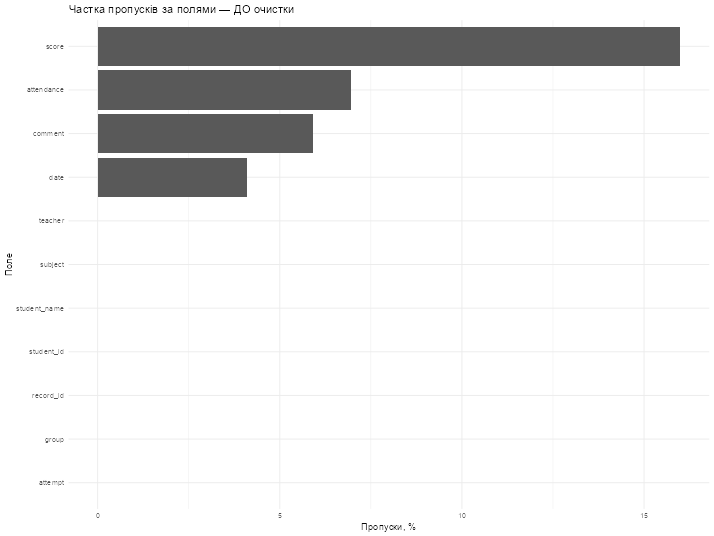

In [81]:
# -----------------------------
# Графік пропусків
# -----------------------------

ggplot(
  missing_before,
  aes(
    x = reorder(field, missing_percent),
    y = missing_percent
  )
) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Частка пропусків за полями — ДО очистки",
    x = "Поле",
    y = "Пропуски, %"
  ) +
  theme_minimal()

In [82]:
# -----------------------------
# Аналіз часових проміжків
# -----------------------------

date_gaps <- tibble(
  date = parsed_dates
) %>%
  filter(!is.na(date)) %>%
  arrange(date) %>%
  mutate(
    gap_days = as.numeric(date - lag(date))
  ) %>%
  filter(!is.na(gap_days))

cat("Мінімальний проміжок:", min(date_gaps$gap_days), "днів\n")
cat("Медіанний проміжок:", median(date_gaps$gap_days), "днів\n")
cat("Максимальний проміжок:", max(date_gaps$gap_days), "днів\n")

Мінімальний проміжок: 0 днів
Медіанний проміжок: 0 днів
Максимальний проміжок: 1 днів


In [83]:
# -----------------------------
# Найбільші часові проміжки
# -----------------------------

date_gaps %>%
  arrange(desc(gap_days)) %>%
  head(10)

# A tibble: 10 × 2
   date       gap_days
   <date>        <dbl>
 1 2024-02-06        1
 2 2024-02-07        1
 3 2024-02-08        1
 4 2024-02-09        1
 5 2024-02-10        1
 6 2024-02-11        1
 7 2024-02-12        1
 8 2024-02-13        1
 9 2024-02-14        1
10 2024-02-15        1

# Блок 3. Очистка даних

In [84]:
# -----------------------------
# ПЛАН ОЧИСТКИ ДАНИХ
# -----------------------------

cleaning_plan <- tibble(
  problem = c(
    "Пропуски score",
    "Пропуски attendance",
    "Пропуски date",
    "Пропуски comment",
    "Повні дублікати",
    "Близькі дублікати",
    "Неправильний тип score",
    "Змішані формати date",
    "Нестабільний attendance",
    "Нестабільний subject",
    "Нестабільний teacher",
    "Проблеми student_name",
    "Некоректний score",
    "Некоректний attempt"
  ),
  
  action = c(
    "Імпутація медіаною за групою та спробою",
    "Імпутація модою за групою",
    "Видалення записів без дати",
    "Очищення пробілів та невидимих символів",
    "Видалення повних дублікатів",
    "Видалення близьких дублікатів за ключем student_id + date + subject + attempt",
    "Перетворення score у numeric",
    "Перетворення всіх дат у Date",
    "Нормалізація до Present / Absent / Late",
    "Нормалізація до DA-101 / DA-102",
    "Нормалізація до Ivanenko / Petrenko",
    "Очищення пробілів, регістру та відновлення імен за student_id",
    "Значення <0 або >100 перетворити на NA та імпутувати",
    "Видалення записів з attempt > 2"
  ),
  
  reason = c(
    "Зберігаємо записи та не втрачаємо спостереження",
    "Категоріальна змінна потребує допустимого значення",
    "Дату неможливо надійно відновити з інших полів",
    "Неінформативні пробіли та невидимі символи видаляються",
    "Точні дублікати не несуть нової інформації",
    "Один студент не повинен мати дубльований запис для тієї самої події",
    "Для статистичних розрахунків потрібен числовий тип",
    "Уніфікуємо формат дат",
    "Одна категорія повинна мати одне представлення",
    "Одна категорія повинна мати одне представлення",
    "Уніфікація назв викладачів",
    "student_id використовується як стабільний ідентифікатор студента",
    "Значення поза діапазоном 0–100 є аномальними",
    "Допустимі тільки спроби 1 та 2"
  )
)

cleaning_plan

# A tibble: 14 × 3
   problem                 action                                         reason
   <chr>                   <chr>                                          <chr> 
 1 Пропуски score          Імпутація медіаною за групою та спробою        Збері…
 2 Пропуски attendance     Імпутація модою за групою                      Катег…
 3 Пропуски date           Видалення записів без дати                     Дату …
 4 Пропуски comment        Очищення пробілів та невидимих символів        Неінф…
 5 Повні дублікати         Видалення повних дублікатів                    Точні…
 6 Близькі дублікати       Видалення близьких дублікатів за ключем stude… Один …
 7 Неправильний тип score  Перетворення score у numeric                   Для с…
 8 Змішані формати date    Перетворення всіх дат у Date                   Уніфі…
 9 Нестабільний attendance Нормалізація до Present / Absent / Late        Одна …
10 Нестабільний subject    Нормалізація до DA-101 / DA-102                Одна …
11 Нестаб

In [85]:
# -----------------------------
# Початок очистки
# -----------------------------

clean_data <- dirty

change_log <- tibble(
  step = character(),
  field = character(),
  rule = character(),
  rows_affected = integer(),
  description = character()
)

cat("Початково рядків:", nrow(clean_data), "\n")
cat("Початково стовпців:", ncol(clean_data), "\n")

Початково рядків: 1882 
Початково стовпців: 11 


In [86]:
# -----------------------------
# Очищення текстових полів
# -----------------------------

text_fields <- c(
  "record_id",
  "student_id",
  "student_name",
  "group",
  "subject",
  "attendance",
  "teacher",
  "comment"
)

for (field in text_fields) {
  clean_data[[field]] <- clean_data[[field]] %>%
    str_replace_all("\u200B", "") %>%
    str_squish()
}

cat("Текстові поля очищено від зайвих пробілів та невидимих символів.\n")

Текстові поля очищено від зайвих пробілів та невидимих символів.


In [87]:
# -----------------------------
# Нормалізація attendance
# -----------------------------

attendance_before <- sum(!is.na(clean_data$attendance))

clean_data <- clean_data %>%
  mutate(
    attendance = case_when(
      is.na(attendance) ~ NA_character_,
      str_to_lower(attendance) %in% c("present") ~ "Present",
      str_to_lower(attendance) %in% c("absent", "abs") ~ "Absent",
      str_to_lower(attendance) %in% c("late") ~ "Late",
      TRUE ~ NA_character_
    )
  )

attendance_after <- sum(!is.na(clean_data$attendance))

change_log <- bind_rows(
  change_log,
  tibble(
    step = "Нормалізація attendance",
    field = "attendance",
    rule = "present → Present; absent/abs → Absent; late → Late",
    rows_affected = sum(
      !is.na(dirty$attendance) &
      dirty$attendance != clean_data$attendance
    ),
    description = "Уніфіковано категорії відвідування"
  )
)

clean_data %>%
  count(attendance, .drop = FALSE)

# A tibble: 4 × 2
  attendance     n
  <chr>      <int>
1 Absent       295
2 Late         230
3 Present     1226
4 NA           131

In [88]:
# -----------------------------
# Нормалізація subject
# -----------------------------

clean_data <- clean_data %>%
  mutate(
    subject_clean = str_to_lower(subject),
    subject_clean = str_replace_all(subject_clean, "[[:space:]-]", ""),
    subject = case_when(
      subject_clean == "da101" ~ "DA-101",
      subject_clean == "da102" ~ "DA-102",
      is.na(subject_clean) ~ NA_character_,
      TRUE ~ NA_character_
    )
  ) %>%
  select(-subject_clean)

change_log <- bind_rows(
  change_log,
  tibble(
    step = "Нормалізація subject",
    field = "subject",
    rule = "da-101 / DA 101 / da 101 → DA-101; da-102 / DA 102 → DA-102",
    rows_affected = sum(
      !is.na(dirty$subject) &
      dirty$subject != clean_data$subject
    ),
    description = "Уніфіковано назви предметів"
  )
)

clean_data %>%
  count(subject, .drop = FALSE)

# A tibble: 2 × 2
  subject     n
  <chr>   <int>
1 DA-101    907
2 DA-102    975

In [ ]:
# -----------------------------
# Нормалізація teacher
# -----------------------------

teacher_before <- clean_data$teacher

clean_data <- clean_data %>%
  mutate(
    teacher = case_when(
      is.na(teacher) ~ NA_character_,
      str_to_lower(str_squish(teacher)) == "ivanenko" ~ "Ivanenko",
      str_to_lower(str_squish(teacher)) == "petrenko" ~ "Petrenko",
      TRUE ~ NA_character_
    )
  )

change_log <- bind_rows(
  change_log,
  tibble(
    step = "Нормалізація teacher",
    field = "teacher",
    rule = "Різний регістр → Ivanenko / Petrenko",
    rows_affected = sum(
      !is.na(teacher_before) &
      teacher_before != clean_data$teacher
    ),
    description = "Уніфіковано назви викладачів"
  )
)

clean_data %>%
  count(teacher, .drop = FALSE)

# A tibble: 2 × 2
  teacher      n
  <chr>    <int>
1 Ivanenko   956
2 Petrenko   926

In [ ]:
# -----------------------------
# очищення та перетворення date
# -----------------------------

date_before <- clean_data$date

clean_data <- clean_data %>%
  mutate(
    date = case_when(
      is.na(date) ~ as.Date(NA),
      
      str_detect(date, "^\\d{4}-\\d{2}-\\d{2}$") ~
        as.Date(date, format = "%Y-%m-%d"),
      
      str_detect(date, "^\\d{2}\\.\\d{2}\\.\\d{4}$") ~
        as.Date(date, format = "%d.%m.%Y"),
      
      TRUE ~ as.Date(NA)
    )
  )

parsed_missing <- sum(is.na(clean_data$date))
parsed_valid <- sum(!is.na(clean_data$date))

change_log <- bind_rows(
  change_log,
  tibble(
    step = "Перетворення date",
    field = "date",
    rule = "YYYY-MM-DD та DD.MM.YYYY → Date",
    rows_affected = sum(
      !is.na(date_before) &
      !is.na(clean_data$date) &
      date_before != as.character(clean_data$date)
    ),
    description = "Уніфіковано всі допустимі формати дат"
  )
)

cat("Коректних дат:", parsed_valid, "\n")
cat("Пропусків дат:", parsed_missing, "\n")
cat("Мінімальна дата:", min(clean_data$date, na.rm = TRUE), "\n")
cat("Максимальна дата:", max(clean_data$date, na.rm = TRUE), "\n")

Коректних дат: 1805 
Пропусків дат: 77 
Мінімальна дата: 19758 
Максимальна дата: 19904 


In [91]:
# -----------------------------
# перевірка дат і видалення пропусків
# -----------------------------

cat("Мінімальна дата:", format(min(clean_data$date, na.rm = TRUE), "%d.%m.%Y"), "\n")
cat("Максимальна дата:", format(max(clean_data$date, na.rm = TRUE), "%d.%m.%Y"), "\n")

rows_before <- nrow(clean_data)

clean_data <- clean_data %>%
  filter(!is.na(date))

rows_after <- nrow(clean_data)

removed_dates <- rows_before - rows_after

change_log <- bind_rows(
  change_log,
  tibble(
    step = "Видалення записів без date",
    field = "date",
    rule = "Видалення рядків з пропущеною датою",
    rows_affected = removed_dates,
    description = "Дату неможливо надійно відновити, тому записи без дати видалено"
  )
)

cat("Видалено записів:", removed_dates, "\n")
cat("Залишилось записів:", nrow(clean_data), "\n")

Мінімальна дата: 05.02.2024 
Максимальна дата: 30.06.2024 
Видалено записів: 77 
Залишилось записів: 1805 


In [92]:
# перетворення score у числовий тип #
#-----------------------------------#
score_before <- clean_data$score

clean_data <- clean_data %>%
  mutate(
    score = score %>%
      str_trim() %>%
      str_replace_all("\\s+", "") %>%
      str_replace(",", ".") %>%
      as.numeric()
  )

cat("Тип score після очищення:", class(clean_data$score), "\n")
cat("Кількість числових значень:", sum(!is.na(clean_data$score)), "\n")
cat("Кількість пропусків:", sum(is.na(clean_data$score)), "\n")

change_log <- bind_rows(
  change_log,
  tibble(
    step = "Перетворення score",
    field = "score",
    rule = "Пробіли видалено, кома → крапка, текст → numeric",
    rows_affected = sum(
      !is.na(score_before) &
      score_before != as.character(clean_data$score)
    ),
    description = "Score приведено до числового типу"
  )
)

summary(clean_data$score)



Тип score після очищення: numeric 
Кількість числових значень: 1514 
Кількість пропусків: 291 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
 -15.00   64.42   74.30   73.78   84.50  130.00     291 

In [93]:
# пошук і виправлення аномальних score#
#-------------------------------------#
invalid_score <- sum(
  !is.na(clean_data$score) &
  (clean_data$score < 0 | clean_data$score > 100)
)

cat("Некоректних score:", invalid_score, "\n")

clean_data <- clean_data %>%
  mutate(
    score = if_else(
      !is.na(score) & (score < 0 | score > 100),
      NA_real_,
      score
    )
  )

change_log <- bind_rows(
  change_log,
  tibble(
    step = "Виправлення аномальних score",
    field = "score",
    rule = "Значення <0 або >100 → NA",
    rows_affected = invalid_score,
    description = "Некоректні оцінки підготовлено до подальшої імпутації"
  )
)

cat("Пропусків score після виправлення:", sum(is.na(clean_data$score)), "\n")
cat("Мінімальний допустимий score:",
    min(clean_data$score, na.rm = TRUE), "\n")
cat("Максимальний допустимий score:",
    max(clean_data$score, na.rm = TRUE), "\n")

Некоректних score: 16 
Пропусків score після виправлення: 307 
Мінімальний допустимий score: 22.5 
Максимальний допустимий score: 100 


In [94]:
# імпутація пропусків score

missing_score_before <- sum(is.na(clean_data$score))

# Медіана score для кожної групи та спроби
score_medians <- clean_data %>%
  group_by(group, attempt) %>%
  summarise(
    median_score = median(score, na.rm = TRUE),
    .groups = "drop"
  )

# Загальна медіана як запасний варіант
overall_score_median <- median(clean_data$score, na.rm = TRUE)

# Додаємо медіани до таблиці та заповнюємо пропуски
clean_data <- clean_data %>%
  left_join(score_medians, by = c("group", "attempt")) %>%
  mutate(
    score = coalesce(score, median_score, overall_score_median)
  ) %>%
  select(-median_score)

missing_score_after <- sum(is.na(clean_data$score))

change_log <- bind_rows(
  change_log,
  tibble(
    step = "Імпутація score",
    field = "score",
    rule = "Пропуски → медіана для group + attempt",
    rows_affected = missing_score_before - missing_score_after,
    description = "Пропущені та аномальні оцінки заповнено груповою медіаною"
  )
)

cat("Пропусків score до імпутації:", missing_score_before, "\n")
cat("Пропусків score після імпутації:", missing_score_after, "\n")
cat("Медіана score:", median(clean_data$score), "\n")
cat("Середнє score:", mean(clean_data$score), "\n")

Пропусків score до імпутації: 307 
Пропусків score після імпутації: 0 
Медіана score: 74.2 
Середнє score: 74.19795 


In [95]:
# очищення attempt

invalid_attempt <- sum(
  !is.na(clean_data$attempt) &
  !clean_data$attempt %in% c(1, 2)
)

cat("Некоректних attempt:", invalid_attempt, "\n")

rows_before <- nrow(clean_data)

clean_data <- clean_data %>%
  filter(attempt %in% c(1, 2))

rows_after <- nrow(clean_data)

removed_attempt <- rows_before - rows_after

change_log <- bind_rows(
  change_log,
  tibble(
    step = "Очищення attempt",
    field = "attempt",
    rule = "Залишити тільки значення 1 та 2",
    rows_affected = removed_attempt,
    description = "Видалено записи з недопустимою спробою"
  )
)

cat("Видалено записів:", removed_attempt, "\n")
cat("Залишилось записів:", nrow(clean_data), "\n")

clean_data %>%
  count(attempt)

Некоректних attempt: 8 
Видалено записів: 8 
Залишилось записів: 1797 


# A tibble: 2 × 2
  attempt     n
    <dbl> <int>
1       1  1523
2       2   274

In [96]:
# імпутація пропусків attendance

missing_attendance_before <- sum(is.na(clean_data$attendance))

# Функція для пошуку моди
get_mode <- function(x) {
  x <- x[!is.na(x)]
  
  if (length(x) == 0) {
    return(NA_character_)
  }
  
  names(sort(table(x), decreasing = TRUE))[1]
}

# Мода attendance для кожної групи
attendance_modes <- clean_data %>%
  group_by(group) %>%
  summarise(
    attendance_mode = get_mode(attendance),
    .groups = "drop"
  )

# Загальна мода як запасний варіант
overall_attendance_mode <- get_mode(clean_data$attendance)

# Заповнюємо пропуски
clean_data <- clean_data %>%
  left_join(attendance_modes, by = "group") %>%
  mutate(
    attendance = coalesce(
      attendance,
      attendance_mode,
      overall_attendance_mode
    )
  ) %>%
  select(-attendance_mode)

missing_attendance_after <- sum(is.na(clean_data$attendance))

change_log <- bind_rows(
  change_log,
  tibble(
    step = "Імпутація attendance",
    field = "attendance",
    rule = "Пропуски → мода за group",
    rows_affected = missing_attendance_before - missing_attendance_after,
    description = "Пропущене відвідування заповнено найчастішою категорією групи"
  )
)

cat("Пропусків attendance до:", missing_attendance_before, "\n")
cat("Пропусків attendance після:", missing_attendance_after, "\n")

clean_data %>%
  count(attendance)

Пропусків attendance до: 125 
Пропусків attendance після: 0 


# A tibble: 3 × 2
  attendance     n
  <chr>      <int>
1 Absent       274
2 Late         225
3 Present     1298

In [97]:
# comment і заповнення пропусків

missing_comment_before <- sum(is.na(clean_data$comment))

clean_data <- clean_data %>%
  mutate(
    comment = if_else(
      is.na(comment) | comment == "",
      "No comment",
      comment
    )
  )

missing_comment_after <- sum(is.na(clean_data$comment))

change_log <- bind_rows(
  change_log,
  tibble(
    step = "Заповнення comment",
    field = "comment",
    rule = "NA або порожній текст → No comment",
    rows_affected = missing_comment_before - missing_comment_after,
    description = "Пропущені коментарі замінено нейтральним значенням"
  )
)

cat("Пропусків comment до:", missing_comment_before, "\n")
cat("Пропусків comment після:", missing_comment_after, "\n")

Пропусків comment до: 107 
Пропусків comment після: 0 


In [98]:
# видалення повних дублікатів

rows_before <- nrow(clean_data)

clean_data <- clean_data %>%
  distinct()

rows_after <- nrow(clean_data)

removed_exact_duplicates <- rows_before - rows_after

change_log <- bind_rows(
  change_log,
  tibble(
    step = "Видалення повних дублікатів",
    field = "all",
    rule = "Повністю однакові рядки → залишити один",
    rows_affected = removed_exact_duplicates,
    description = "Видалено повні дублікати записів"
  )
)

cat("Рядків до:", rows_before, "\n")
cat("Видалено повних дублікатів:", removed_exact_duplicates, "\n")
cat("Рядків після:", rows_after, "\n")

Рядків до: 1797 
Видалено повних дублікатів: 42 
Рядків після: 1755 


In [99]:
# пошук близьких дублікатів

near_duplicates <- clean_data %>%
  group_by(
    student_id,
    date,
    subject,
    attempt,
    score,
    comment
  ) %>%
  mutate(duplicate_count = n()) %>%
  ungroup() %>%
  filter(duplicate_count > 1)

cat("Рядків, які входять у групи близьких дублікатів:",
    nrow(near_duplicates), "\n")

cat("Кількість груп близьких дублікатів:",
    n_distinct(
      paste(
        near_duplicates$student_id,
        near_duplicates$date,
        near_duplicates$subject,
        near_duplicates$attempt,
        near_duplicates$score,
        near_duplicates$comment,
        sep = "|"
      )
    ),
    "\n")

near_duplicates %>%
  select(
    record_id,
    student_id,
    date,
    subject,
    attempt,
    attendance,
    score,
    comment
  ) %>%
  arrange(student_id, date, subject, attempt) %>%
  head(20)

Рядків, які входять у групи близьких дублікатів: 70 
Кількість груп близьких дублікатів: 35 


# A tibble: 20 × 8
   record_id student_id date       subject attempt attendance score comment     
   <chr>     <chr>      <date>     <chr>     <dbl> <chr>      <dbl> <chr>       
 1 REC1502   ST009      2024-04-30 DA-101        1 Present     59.5 Good work   
 2 NEAR0036  ST009      2024-04-30 DA-101        1 Present     59.5 Good work   
 3 REC0827   ST035      2024-05-25 DA-101        1 Late        71.8 Additional …
 4 NEAR0010  ST035      2024-05-25 DA-101        1 Late        71.8 Additional …
 5 REC0744   ST039      2024-02-15 DA-101        2 Present     97.2 No comment  
 6 NEAR0027  ST039      2024-02-15 DA-101        2 Present     97.2 No comment  
 7 REC0383   ST045      2024-06-15 DA-102        1 Present     74.2 Was late    
 8 NEAR0033  ST045      2024-06-15 DA-102        1 Present     74.2 Was late    
 9 REC1660   ST049      2024-03-09 DA-101        1 Present     82.9 Was late    
10 NEAR0019  ST049      2024-03-09 DA-101        1 Present     82.9 Was late    
11 REC157

In [100]:
# видалення близьких дублікатів

rows_before <- nrow(clean_data)

clean_data <- clean_data %>%
  group_by(
    student_id,
    date,
    subject,
    attempt,
    score,
    comment
  ) %>%
  slice(1) %>%
  ungroup()

rows_after <- nrow(clean_data)

removed_near_duplicates <- rows_before - rows_after

change_log <- bind_rows(
  change_log,
  tibble(
    step = "Видалення близьких дублікатів",
    field = "student_id + date + subject + attempt + score + comment",
    rule = "Для кожної групи залишити перший запис",
    rows_affected = removed_near_duplicates,
    description = "Видалено повторні записи однієї навчальної події"
  )
)

cat("Рядків до:", rows_before, "\n")
cat("Видалено близьких дублікатів:", removed_near_duplicates, "\n")
cat("Рядків після:", rows_after, "\n")

Рядків до: 1755 
Видалено близьких дублікатів: 35 
Рядків після: 1720 


In [101]:
# нормалізація student_name#
#---------------------------#

# Спочатку очищаємо регістр і пробіли
clean_data <- clean_data %>%
  mutate(
    student_name = str_to_title(str_squish(student_name))
  )

# Для кожного student_id знаходимо найчастіше ім'я
canonical_names <- clean_data %>%
  filter(!is.na(student_name), student_name != "") %>%
  count(student_id, student_name, sort = TRUE) %>%
  group_by(student_id) %>%
  slice_max(order_by = n, n = 1, with_ties = FALSE) %>%
  ungroup() %>%
  select(student_id, canonical_name = student_name)

# Зберігаємо старі імена для підрахунку змін
names_before <- clean_data$student_name

# Замінюємо імена на еталонні
clean_data <- clean_data %>%
  select(-student_name) %>%
  left_join(canonical_names, by = "student_id") %>%
  rename(student_name = canonical_name)

names_changed <- sum(
  !is.na(names_before) &
  !is.na(clean_data$student_name) &
  names_before != clean_data$student_name
)

change_log <- bind_rows(
  change_log,
  tibble(
    step = "Нормалізація student_name",
    field = "student_name",
    rule = "Очищення регістру + найчастіше ім'я для кожного student_id",
    rows_affected = names_changed,
    description = "Виправлено нестабільні та помилкові варіанти імен"
  )
)

cat("Змінено імен:", names_changed, "\n")
cat("Унікальних студентів:", n_distinct(clean_data$student_id), "\n")

Змінено імен: 165 
Унікальних студентів: 348 


In [102]:
# фінальна перевірка 

validation_results <- tibble(
  check = c(
    "Немає пропусків date",
    "Немає пропусків attendance",
    "Немає пропусків score",
    "Немає пропусків comment",
    "score у межах 0–100",
    "attempt тільки 1 або 2",
    "subject тільки DA-101 / DA-102",
    "attendance тільки Present / Absent / Late",
    "teacher тільки Ivanenko / Petrenko",
    "Немає повних дублікатів"
  ),
  
  result = c(
    all(!is.na(clean_data$date)),
    all(!is.na(clean_data$attendance)),
    all(!is.na(clean_data$score)),
    all(!is.na(clean_data$comment)),
    all(clean_data$score >= 0 & clean_data$score <= 100),
    all(clean_data$attempt %in% c(1, 2)),
    all(clean_data$subject %in% c("DA-101", "DA-102")),
    all(clean_data$attendance %in% c("Present", "Absent", "Late")),
    all(clean_data$teacher %in% c("Ivanenko", "Petrenko")),
    nrow(clean_data) == nrow(distinct(clean_data))
  )
)

validation_results

# A tibble: 10 × 2
   check                                     result
   <chr>                                     <lgl> 
 1 Немає пропусків date                      TRUE  
 2 Немає пропусків attendance                TRUE  
 3 Немає пропусків score                     TRUE  
 4 Немає пропусків comment                   TRUE  
 5 score у межах 0–100                       TRUE  
 6 attempt тільки 1 або 2                    TRUE  
 7 subject тільки DA-101 / DA-102            TRUE  
 8 attendance тільки Present / Absent / Late TRUE  
 9 teacher тільки Ivanenko / Petrenko        TRUE  
10 Немає повних дублікатів                   TRUE  

In [103]:
# збереження очищених даних і change_log

# Зберігаємо очищений датасет
write_csv(
  clean_data,
  "data/clean/generated_clean.csv"
)

# Зберігаємо журнал змін
write_csv(
  change_log,
  "data/clean/change_log.csv"
)

cat("Очищений датасет збережено:\n")
cat("data/clean/generated_clean.csv\n\n")

cat("Журнал змін збережено:\n")
cat("data/clean/change_log.csv\n\n")

cat("Фінальна кількість рядків:", nrow(clean_data), "\n")
cat("Кількість стовпців:", ncol(clean_data), "\n")

Очищений датасет збережено:
data/clean/generated_clean.csv

Журнал змін збережено:
data/clean/change_log.csv

Фінальна кількість рядків: 1720 
Кількість стовпців: 11 


# Блок 4 — статистика після очищення

In [104]:
score_after <- clean_data %>%
  summarise(
    count = sum(!is.na(score)),
    mean = mean(score, na.rm = TRUE),
    median = median(score, na.rm = TRUE),
    sd = sd(score, na.rm = TRUE),
    min = min(score, na.rm = TRUE),
    max = max(score, na.rm = TRUE),
    Q1 = quantile(score, 0.25, na.rm = TRUE),
    Q3 = quantile(score, 0.75, na.rm = TRUE),
    IQR = IQR(score, na.rm = TRUE)
  )

score_after

# A tibble: 1 × 9
  count  mean median    sd   min   max    Q1    Q3   IQR
  <int> <dbl>  <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>
1  1720  74.2   74.2  13.4  22.5   100  66.4    82  15.6

In [105]:
# порівняння ДО / ПІСЛЯ

comparison <- tibble(
  metric = c(
    "Кількість записів",
    "Середнє score",
    "Медіана score",
    "Стандартне відхилення",
    "Мінімум",
    "Максимум",
    "Q1",
    "Q3",
    "IQR"
  ),
  
  before = c(
    1882,
    73.6619,
    74.1,
    16.5449,
    -15,
    130,
    64.3,
    84.5,
    20.2
  ),
  
  after = c(
    1720,
    score_after$mean,
    score_after$median,
    score_after$sd,
    score_after$min,
    score_after$max,
    score_after$Q1,
    score_after$Q3,
    score_after$IQR
  )
)

comparison

# A tibble: 9 × 3
  metric                before  after
  <chr>                  <dbl>  <dbl>
1 Кількість записів     1882   1720  
2 Середнє score           73.7   74.2
3 Медіана score           74.1   74.2
4 Стандартне відхилення   16.5   13.4
5 Мінімум                -15     22.5
6 Максимум               130    100  
7 Q1                      64.3   66.4
8 Q3                      84.5   82  
9 IQR                     20.2   15.6

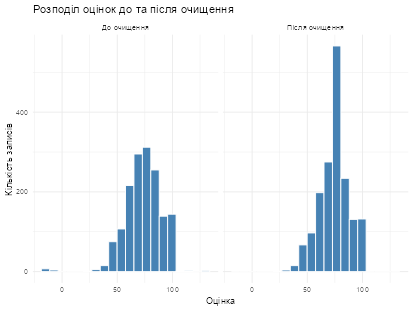

In [107]:
# графік розподілу score до та після очищення

score_plot_data <- tibble(
  score = c(
    dirty_score_numeric[!is.na(dirty_score_numeric)],
    clean_data$score
  ),
  status = c(
    rep("До очищення", sum(!is.na(dirty_score_numeric))),
    rep("Після очищення", nrow(clean_data))
  )
)

ggplot(score_plot_data, aes(x = score)) +
  geom_histogram(
    bins = 20,
    fill = "steelblue",
    color = "white"
  ) +
  facet_wrap(~status) +
  labs(
    title = "Розподіл оцінок до та після очищення",
    x = "Оцінка",
    y = "Кількість записів"
  ) +
  theme_minimal()

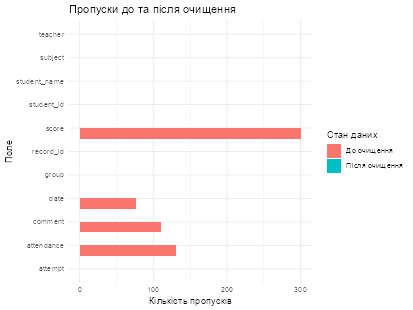

In [108]:
# порівняння пропусків

missing_before_plot <- dirty %>%
  summarise(across(everything(), ~sum(is.na(.)))) %>%
  pivot_longer(
    cols = everything(),
    names_to = "field",
    values_to = "missing"
  ) %>%
  mutate(status = "До очищення")

missing_after_plot <- clean_data %>%
  summarise(across(everything(), ~sum(is.na(.)))) %>%
  pivot_longer(
    cols = everything(),
    names_to = "field",
    values_to = "missing"
  ) %>%
  mutate(status = "Після очищення")

missing_plot_data <- bind_rows(
  missing_before_plot,
  missing_after_plot
)

ggplot(
  missing_plot_data,
  aes(x = field, y = missing, fill = status)
) +
  geom_col(position = "dodge") +
  coord_flip() +
  labs(
    title = "Пропуски до та після очищення",
    x = "Поле",
    y = "Кількість пропусків",
    fill = "Стан даних"
  ) +
  theme_minimal()

# Висновки

У результаті очищення набору даних кількість записів зменшилася з 1882 до 1720 через видалення записів із відсутньою датою, некоректними спробами та дублікати. Пропуски у полях `score`, `attendance` та `comment` були оброблені відповідно до визначених правил очищення та імпутації. Значення оцінок були приведені до числового типу, а некоректні значення поза діапазоном 0–100 видалені та замінені за правилом імпутації. Категоріальні значення `attendance`, `subject` і `teacher` були нормалізовані до єдиного формату. Середнє значення оцінки змінилося з 73.66 до 74.22, а медіана — з 74.1 до 74.2. Стандартне відхилення зменшилося з 16.54 до 13.44, що відповідає зменшенню розкиду оцінок після усунення аномальних значень. Після очищення всі 10 перевірок якості даних дали результат `TRUE`, тому очищений набір відповідає встановленим правилам валідації.


# Блок 5 — KPI.

In [110]:
# 1-3 KPI: кількість студентів/записів, середній/медіанний бал і частку Present.

kpi_1_3 <- tibble(
  KPI = c(
    "Кількість студентів",
    "Кількість записів",
    "Середнє score",
    "Медіана score",
    "Частка Present"
  ),
  Value = c(
    n_distinct(clean_data$student_id),
    nrow(clean_data),
    mean(clean_data$score, na.rm = TRUE),
    median(clean_data$score, na.rm = TRUE),
    mean(clean_data$attendance == "Present") * 100
  )
)

kpi_1_3

# A tibble: 5 × 2
  KPI                  Value
  <chr>                <dbl>
1 Кількість студентів  348  
2 Кількість записів   1720  
3 Середнє score         74.2
4 Медіана score         74.2
5 Частка Present        72.2

In [111]:
# KPI 4: частка Late за кожною групою
kpi_4 <- clean_data %>%
  group_by(group) %>%
  summarise(
    late_share = mean(attendance == "Late") * 100,
    .groups = "drop"
  )

kpi_4

# A tibble: 4 × 2
  group late_share
  <chr>      <dbl>
1 K-21       12.6 
2 K-22       13.5 
3 K-23        9.89
4 K-24       12.7 

In [112]:
# KPI 5: повторні спроби
kpi_5 <- clean_data %>%
  summarise(
    retake_share = mean(attempt == 2) * 100,
    retake_mean_score = mean(score[attempt == 2], na.rm = TRUE)
  )

kpi_5

# A tibble: 1 × 2
  retake_share retake_mean_score
         <dbl>             <dbl>
1         15.1              76.1

In [113]:
# KPI 6 — студенти з 

student_scores <- clean_data %>%
  group_by(student_id, student_name, group) %>%
  summarise(
    mean_score = mean(score, na.rm = TRUE),
    .groups = "drop"
  )

kpi_6 <- student_scores %>%
  filter(mean_score < 60) %>%
  summarise(
    risky_students = n(),
    risky_mean_score = mean(mean_score)
  )

kpi_6

# A tibble: 1 × 2
  risky_students risky_mean_score
           <int>            <dbl>
1             10             55.5

In [114]:
# KPI 7 — TOP-5

kpi_7 <- clean_data %>%
  group_by(student_id, student_name, group, subject) %>%
  summarise(
    score_attempt1 = if (any(attempt == 1)) score[attempt == 1][1] else NA_real_,
    score_attempt2 = if (any(attempt == 2)) score[attempt == 2][1] else NA_real_,
    .groups = "drop"
  ) %>%
  filter(
    !is.na(score_attempt1),
    !is.na(score_attempt2)
  ) %>%
  mutate(
    improvement = score_attempt2 - score_attempt1
  ) %>%
  arrange(desc(improvement)) %>%
  slice_head(n = 5)

kpi_7

# A tibble: 5 × 7
  student_id student_name            group subject score_attempt1 score_attempt2
  <chr>      <chr>                   <chr> <chr>            <dbl>          <dbl>
1 ST047      Іваненко Богдан Олекса… K-24  DA-102            41.9          100  
2 ST268      Петренко Іван Іванівна  K-21  DA-102            39.4           86.8
3 ST029      Петренко Дарина Іванов… K-22  DA-102            52.8          100  
4 ST335      Мельник Богдан Миколаї… K-24  DA-101            55.6           99.1
5 ST106      Савченко Анна Дмитрович K-22  DA-101            32.9           72.1
# ℹ 1 more variable: improvement <dbl>

In [115]:
# KPI 8 — варіативність оцінок за викладачами.

kpi_8 <- clean_data %>%
  group_by(teacher) %>%
  summarise(
    mean_score = mean(score, na.rm = TRUE),
    sd_score = sd(score, na.rm = TRUE),
    .groups = "drop"
  )

kpi_8

# A tibble: 2 × 3
  teacher  mean_score sd_score
  <chr>         <dbl>    <dbl>
1 Ivanenko       74.0     13.8
2 Petrenko       74.4     13.0

In [116]:
# KPI 9 — розподіл оцінок за предметами.

kpi_9 <- clean_data %>%
  group_by(subject) %>%
  summarise(
    count = n(),
    mean_score = mean(score, na.rm = TRUE),
    median_score = median(score, na.rm = TRUE),
    sd_score = sd(score, na.rm = TRUE),
    .groups = "drop"
  )

kpi_9

# A tibble: 2 × 5
  subject count mean_score median_score sd_score
  <chr>   <int>      <dbl>        <dbl>    <dbl>
1 DA-101    825       73.9         74.2     13.3
2 DA-102    895       74.5         74.5     13.6

In [117]:
# KPI 10 — відсоток очищених записів

kpi_10 <- tibble(
  KPI = "Відсоток збережених записів після очищення",
  Value = nrow(clean_data) / nrow(dirty) * 100
)

kpi_10

# A tibble: 1 × 2
  KPI                                        Value
  <chr>                                      <dbl>
1 Відсоток збережених записів після очищення  91.4

In [118]:
# KPI до/після

kpi_before_after <- tibble(
  KPI = c(
    "Середнє score",
    "Медіана score",
    "Стандартне відхилення"
  ),
  До_очищення = c(
    mean(dirty_score_numeric, na.rm = TRUE),
    median(dirty_score_numeric, na.rm = TRUE),
    sd(dirty_score_numeric, na.rm = TRUE)
  ),
  Після_очищення = c(
    mean(clean_data$score, na.rm = TRUE),
    median(clean_data$score, na.rm = TRUE),
    sd(clean_data$score, na.rm = TRUE)
  )
)

kpi_before_after

# A tibble: 3 × 3
  KPI                   До_очищення Після_очищення
  <chr>                       <dbl>          <dbl>
1 Середнє score                73.7           74.2
2 Медіана score                74.1           74.2
3 Стандартне відхилення        16.5           13.4

In [119]:
# всі KPI

kpi_all <- bind_rows(
  tibble(
    KPI = "Кількість студентів",
    Value = n_distinct(clean_data$student_id)
  ),
  tibble(
    KPI = "Кількість записів",
    Value = nrow(clean_data)
  ),
  tibble(
    KPI = "Середнє score",
    Value = mean(clean_data$score, na.rm = TRUE)
  ),
  tibble(
    KPI = "Медіана score",
    Value = median(clean_data$score, na.rm = TRUE)
  ),
  tibble(
    KPI = "Частка Present (%)",
    Value = mean(clean_data$attendance == "Present") * 100
  ),
  tibble(
    KPI = "Повторні спроби (%)",
    Value = mean(clean_data$attempt == 2) * 100
  ),
  tibble(
    KPI = "Середній score повторних спроб",
    Value = mean(clean_data$score[clean_data$attempt == 2], na.rm = TRUE)
  ),
  tibble(
    KPI = "Ризикові студенти (<60)",
    Value = kpi_6$risky_students
  ),
  tibble(
    KPI = "Середній score ризикових студентів",
    Value = kpi_6$risky_mean_score
  ),
  tibble(
    KPI = "Збережено записів після очищення (%)",
    Value = nrow(clean_data) / nrow(dirty) * 100
  )
)

kpi_all

write_csv(kpi_all, "data/clean/kpi_results.csv")

In [121]:
clean_saved <- read_csv(
  "data/clean/generated_clean.csv",
  show_col_types = FALSE
)

cat("Рядків у пам'яті:", nrow(clean_data), "\n")
cat("Рядків у CSV:", nrow(clean_saved), "\n")
cat("Стовпців:", ncol(clean_saved), "\n\n")

cat("Перевірка збігу:", identical(clean_data, clean_saved), "\n")

Рядків у пам'яті: 1720 
Рядків у CSV: 1720 
Стовпців: 11 

Перевірка збігу: FALSE 


In [ ]:
# перевірка збереженого CSV

cat("Рядків:", nrow(clean_saved), "=", nrow(clean_data), "\n")
cat("Стовпців:", ncol(clean_saved), "=", ncol(clean_data), "\n")

cat(
  "Record ID збігаються:",
  identical(
    sort(clean_data$record_id),
    sort(clean_saved$record_id)
  ),
  "\n"
)

cat(
  "Score збігається:",
  isTRUE(
    all.equal(
      sort(clean_data$score),
      sort(clean_saved$score),
      check.attributes = FALSE
    )
  ),
  "\n"
)

cat(
  "Дата збігається:",
  identical(
    sort(as.character(clean_data$date)),
    sort(as.character(clean_saved$date))
  ),
  "\n"
)

Рядків: 1720 = 1720 
Стовпців: 11 = 11 
Record ID збігаються: TRUE 
Score збігається: TRUE 
Дата збігається: TRUE 


In [123]:
# фінальна статистика

final_stats <- tibble(
  Показник = c(
    "Початкова кількість записів",
    "Кінцева кількість записів",
    "Кількість унікальних студентів",
    "Середнє score до очищення",
    "Середнє score після очищення",
    "Медіана score до очищення",
    "Медіана score після очищення",
    "SD до очищення",
    "SD після очищення",
    "Частка Present",
    "Частка повторних спроб",
    "Ризикові студенти",
    "Збережено записів"
  ),
  Значення = c(
    nrow(dirty),
    nrow(clean_data),
    n_distinct(clean_data$student_id),
    mean(dirty_score_numeric, na.rm = TRUE),
    mean(clean_data$score, na.rm = TRUE),
    median(dirty_score_numeric, na.rm = TRUE),
    median(clean_data$score, na.rm = TRUE),
    sd(dirty_score_numeric, na.rm = TRUE),
    sd(clean_data$score, na.rm = TRUE),
    mean(clean_data$attendance == "Present") * 100,
    mean(clean_data$attempt == 2) * 100,
    kpi_6$risky_students,
    nrow(clean_data) / nrow(dirty) * 100
  )
)

final_stats

# A tibble: 13 × 2
   Показник                       Значення
   <chr>                             <dbl>
 1 Початкова кількість записів      1882  
 2 Кінцева кількість записів        1720  
 3 Кількість унікальних студентів    348  
 4 Середнє score до очищення          73.7
 5 Середнє score після очищення       74.2
 6 Медіана score до очищення          74.1
 7 Медіана score після очищення       74.2
 8 SD до очищення                     16.5
 9 SD після очищення                  13.4
10 Частка Present                     72.2
11 Частка повторних спроб             15.1
12 Ризикові студенти                  10  
13 Збережено записів                  91.4

In [124]:
clean_test <- clean_data

# Повторне застосування правил нормалізації
clean_test <- clean_test %>%
  mutate(
    student_name = str_to_title(str_squish(student_name)),
    attendance = case_when(
      str_to_lower(attendance) == "present" ~ "Present",
      str_to_lower(attendance) == "absent" ~ "Absent",
      str_to_lower(attendance) == "late" ~ "Late",
      TRUE ~ attendance
    ),
    subject = case_when(
      str_to_lower(str_replace_all(subject, "[[:space:]-]", "")) == "da101" ~ "DA-101",
      str_to_lower(str_replace_all(subject, "[[:space:]-]", "")) == "da102" ~ "DA-102",
      TRUE ~ subject
    ),
    teacher = case_when(
      str_to_lower(str_squish(teacher)) == "ivanenko" ~ "Ivanenko",
      str_to_lower(str_squish(teacher)) == "petrenko" ~ "Petrenko",
      TRUE ~ teacher
    )
  )

cat(
  "Кількість рядків:", nrow(clean_data), "→", nrow(clean_test), "\n"
)

cat(
  "Зміни в student_name:",
  sum(clean_data$student_name != clean_test$student_name),
  "\n"
)

cat(
  "Зміни в attendance:",
  sum(clean_data$attendance != clean_test$attendance),
  "\n"
)

cat(
  "Зміни в subject:",
  sum(clean_data$subject != clean_test$subject),
  "\n"
)

cat(
  "Зміни в teacher:",
  sum(clean_data$teacher != clean_test$teacher),
  "\n"
)

Кількість рядків: 1720 → 1720 
Зміни в student_name: 0 
Зміни в attendance: 0 
Зміни в subject: 0 
Зміни в teacher: 0 


In [125]:
kpi_comments <- tibble(
  KPI = c(
    "Кількість студентів",
    "Кількість записів",
    "Середнє score",
    "Медіана score",
    "Частка Present",
    "Повторні спроби",
    "Середній score повторних спроб",
    "Ризикові студенти",
    "Середній score ризикових студентів",
    "Збережено записів після очищення"
  ),
  
  Value = c(
    n_distinct(clean_data$student_id),
    nrow(clean_data),
    mean(clean_data$score, na.rm = TRUE),
    median(clean_data$score, na.rm = TRUE),
    mean(clean_data$attendance == "Present") * 100,
    mean(clean_data$attempt == 2) * 100,
    mean(clean_data$score[clean_data$attempt == 2], na.rm = TRUE),
    kpi_6$risky_students,
    kpi_6$risky_mean_score,
    nrow(clean_data) / nrow(dirty) * 100
  ),
  
  Comment = c(
    "У наборі даних представлено 348 унікальних студентів.",
    "Після очищення залишилося 1720 коректних записів.",
    "Середня оцінка після очищення становить 74.22.",
    "Медіанна оцінка становить 74.2.",
    "Близько 72.21% записів мають статус Present.",
    "Частка записів із другою спробою становить 15.12%.",
    "Середній результат повторної спроби становить 76.09.",
    "10 студентів мають середній бал нижче 60.",
    "Середній бал студентів із групи ризику становить 55.54.",
    "Після очищення збережено 91.39% початкових записів."
  )
)

kpi_comments

# A tibble: 10 × 3
   KPI                                 Value Comment                            
   <chr>                               <dbl> <chr>                              
 1 Кількість студентів                 348   У наборі даних представлено 348 ун…
 2 Кількість записів                  1720   Після очищення залишилося 1720 кор…
 3 Середнє score                        74.2 Середня оцінка після очищення стан…
 4 Медіана score                        74.2 Медіанна оцінка становить 74.2.    
 5 Частка Present                       72.2 Близько 72.21% записів мають стату…
 6 Повторні спроби                      15.1 Частка записів із другою спробою с…
 7 Середній score повторних спроб       76.1 Середній результат повторної спроб…
 8 Ризикові студенти                    10   10 студентів мають середній бал ни…
 9 Середній score ризикових студентів   55.5 Середній бал студентів із групи ри…
10 Збережено записів після очищення     91.4 Після очищення збережено 91.39% по…

In [126]:
write_csv(
  kpi_comments,
  "data/clean/kpi_results_commented.csv"
)